# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

# Load data

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)

df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

df = df.select_dtypes(include=np.number)
df = df.dropna(axis=0)
#df = df.sample(50)

df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Lot Frontage              1089 non-null   float64
 1   Lot Area                  1089 non-null   int64  
 2   Overall Qual              1089 non-null   int64  
 3   Overall Cond              1089 non-null   int64  
 4   Year                      1089 non-null   int64  
 5   Year Remod Add            1089 non-null   int64  
 6   Masonry/Veneer Area       1089 non-null   float64
 7   Basement Finished Area    1089 non-null   int64  
 8   Basement Unfinished Area  1089 non-null   int64  
 9   Basement Area             1089 non-null   int64  
 10  1st Floor Area            1089 non-null   int64  
 11  2nd Floor Area            1089 non-null   int64  
 12  Living Area Above Grade   1089 non-null   int64  
 13  Basement Full Baths       1089 non-null   int64  
 14  Basement

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
0,65.0,8450,7,5,2003,2003,196.0,706,150,856,856,854,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,208500
1,80.0,9600,6,8,1976,1976,0.0,978,284,1262,1262,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,181500
2,68.0,11250,7,5,2001,2002,162.0,486,434,920,920,866,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,223500
3,60.0,9550,7,5,1915,1970,0.0,216,540,756,961,756,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,140000
4,84.0,14260,8,5,2000,2000,350.0,655,490,1145,1145,1053,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,250000


# Perform PCA with and without standard scaling

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# Data matrix
# -------------------------------------------------
X = df.values

# -------------------------------------------------
# PCA WITHOUT standardization (covariance PCA)
# -------------------------------------------------
pca_raw = PCA()
X_pca_raw = pca_raw.fit_transform(X)

# -------------------------------------------------
# PCA WITH standardization (correlation PCA)
# -------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_std = PCA()
X_pca_std = pca_std.fit_transform(X_std)

# -------------------------------------------------
# Put transformed data into DataFrames
# -------------------------------------------------
df_pca_raw = pd.DataFrame(
    X_pca_raw,
    columns=[f"PC{i+1}" for i in range(X_pca_raw.shape[1])],
    index=df.index
)

df_pca_std = pd.DataFrame(
    X_pca_std,
    columns=[f"PC{i+1}" for i in range(X_pca_std.shape[1])],
    index=df.index
)

print("PCA WITHOUT standardization:")
display(df_pca_raw.head())

print("\nPCA WITH standardization:")
display(df_pca_std.head())

PCA WITHOUT standardization:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31
0,20736.576896,-2367.719548,270.593716,-782.176917,36.657896,-160.900200,54.483730,41.685880,-107.063168,-3.536863,-14.631750,-35.920103,-25.582549,-1.483822,-7.188506,29.340380,-4.308075,1.810019,2.993788,0.223943,0.938136,-0.186692,0.334652,-0.284179,-0.569761,0.104035,0.281915,-0.075254,0.215104,0.103672,-0.123316
1,-6217.325339,-412.790122,-750.125606,-247.533919,-30.155799,-52.279642,-127.991120,-2.419885,198.626621,-51.432012,16.418136,15.820131,-23.294385,-6.864510,0.092754,-11.233236,3.556361,12.976508,-8.108220,-0.160960,0.292754,2.488553,-0.313859,0.101535,0.381754,-0.738777,-0.799039,0.482619,0.018043,0.635332,-0.056996
2,35813.004003,-14.680848,471.282701,-462.032333,-46.139903,-145.512918,30.326890,81.385173,-108.737403,-4.868106,3.882729,-24.971563,-42.884695,-1.785180,-7.594181,21.866494,-2.560042,-0.444663,2.104492,-1.801098,-1.208055,-0.199293,-0.126347,0.081150,0.566054,0.223377,0.524250,-0.241187,0.243035,0.162244,0.048005
3,-47700.217960,756.284089,555.397043,-176.039809,292.929062,29.003579,-8.542783,215.860779,-91.772132,-4.844631,175.971485,38.956678,147.590131,-28.172948,-0.394586,27.061960,0.271137,-19.484669,-2.485436,37.523670,-0.320316,-0.382322,1.725862,0.272933,0.426611,0.289618,0.815206,0.660319,-0.696779,0.041248,-0.160190
4,62394.240271,2215.559793,505.099605,-447.750987,357.221403,-152.023054,202.740809,204.277416,55.887267,1.794635,-11.820151,-16.163493,-11.551188,-8.836625,-1.708575,2.887094,3.906308,2.676684,2.076916,-6.583818,0.766396,0.132067,0.771158,-0.042202,0.288603,0.329907,0.418626,0.034787,-0.106036,0.013561,-0.097587



PCA WITH standardization:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31
0,1.256370,0.327950,-1.012227,-2.320284,1.370541,0.475989,0.217682,0.464766,-0.471644,0.067774,-0.388237,0.131560,-0.077359,0.589347,-0.864902,0.478045,0.373017,0.573637,-0.140366,-0.143796,0.350521,0.208662,0.082689,0.146087,0.227089,-0.201395,0.383479,0.207102,-0.069359,-0.037445,-0.006874
1,-0.431597,-0.709005,1.248115,-0.205511,-1.648461,-3.771208,-2.148329,-0.551716,0.200606,1.469272,-0.249635,0.848896,0.247449,-0.611556,-0.271484,0.489437,-0.331423,-0.699463,-0.134066,-0.195244,-0.521117,-1.288696,0.524716,0.176367,0.344353,0.216231,0.571370,-0.143376,0.009289,-0.088621,0.011658
2,1.437007,0.180053,-0.866147,-1.864183,0.591850,0.610808,0.366791,0.556652,-0.085016,-0.158193,0.038664,0.160707,-0.243410,-0.211741,-1.046006,-0.265623,-0.138563,0.156697,-0.108330,0.452323,0.436963,-0.163788,0.735943,0.263587,-0.176105,-0.157108,-0.641272,0.160785,-0.016639,-0.066571,0.000435
3,-0.661025,1.172789,0.769278,0.298204,0.916601,-0.051092,2.936531,-0.053382,1.155678,-1.702038,-2.251283,1.627714,0.003850,-1.875248,0.257100,0.658957,-0.428061,-0.217366,-0.628104,0.984449,0.674356,0.395178,-0.602328,0.863725,-0.337984,-0.566265,0.211771,-1.240582,-0.664818,-0.071223,-0.068048
4,4.199228,1.336000,-0.175181,-1.567444,1.086977,-0.118004,0.175569,-0.004749,-0.129634,-0.447728,0.277271,0.698012,-0.242131,0.354808,0.314404,0.302163,-0.392991,-0.283756,-0.394873,0.748950,0.498418,0.078806,0.032579,-0.041342,-0.348720,-0.509267,0.255471,0.120642,0.115924,-0.035055,-0.010463


# View PC compoents of original columns (loadings)

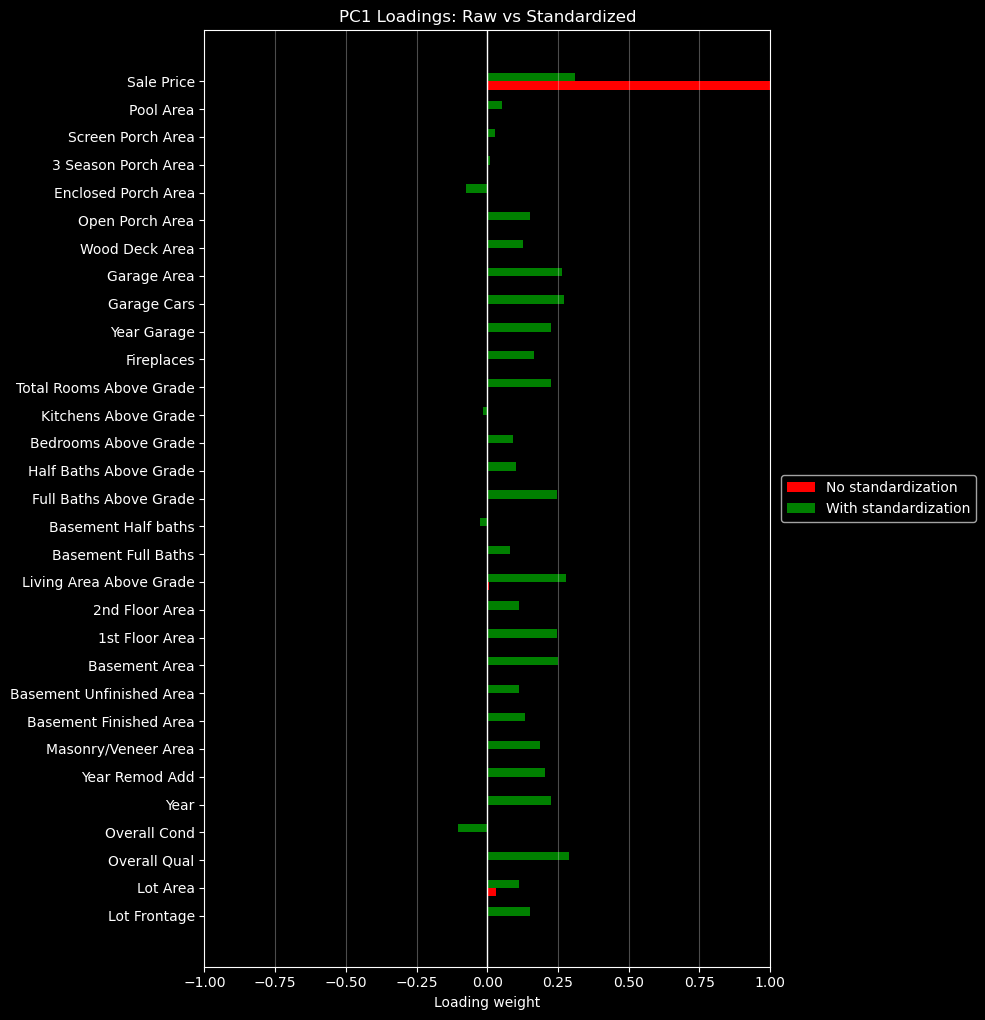

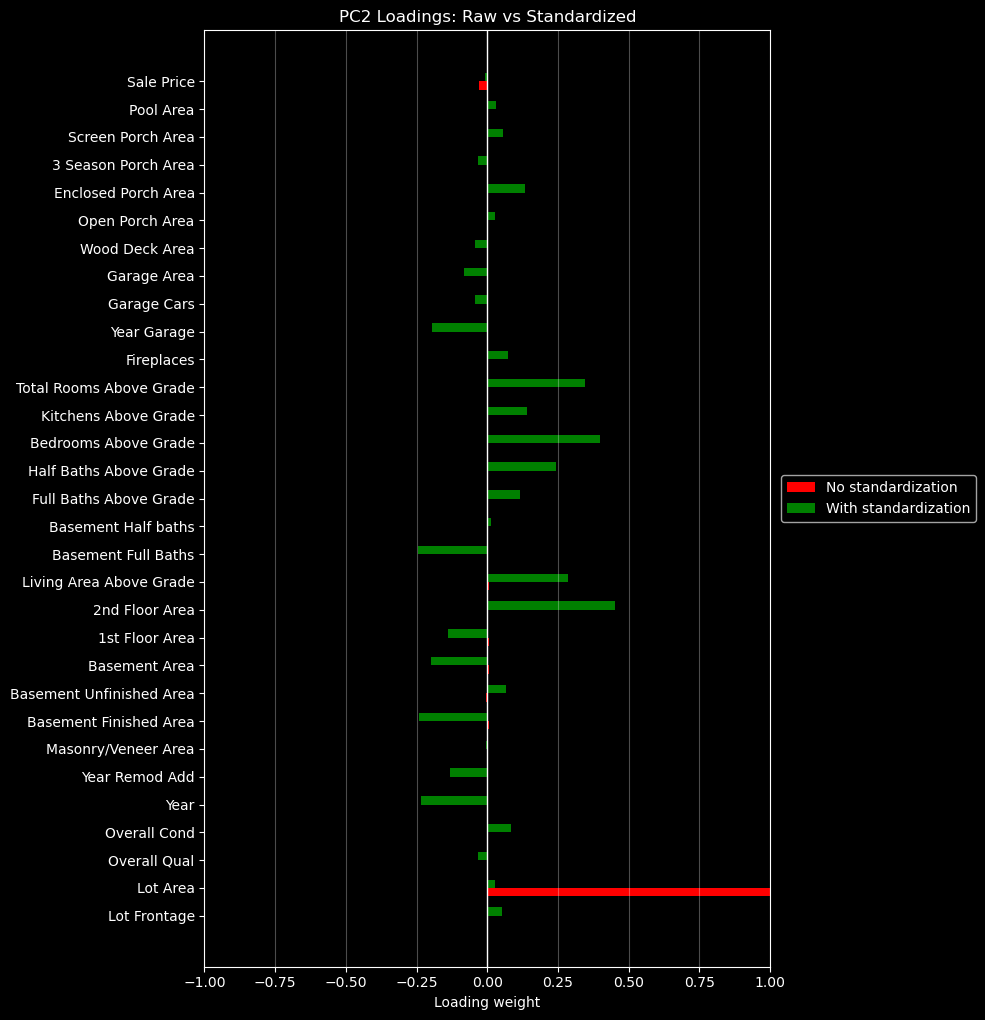

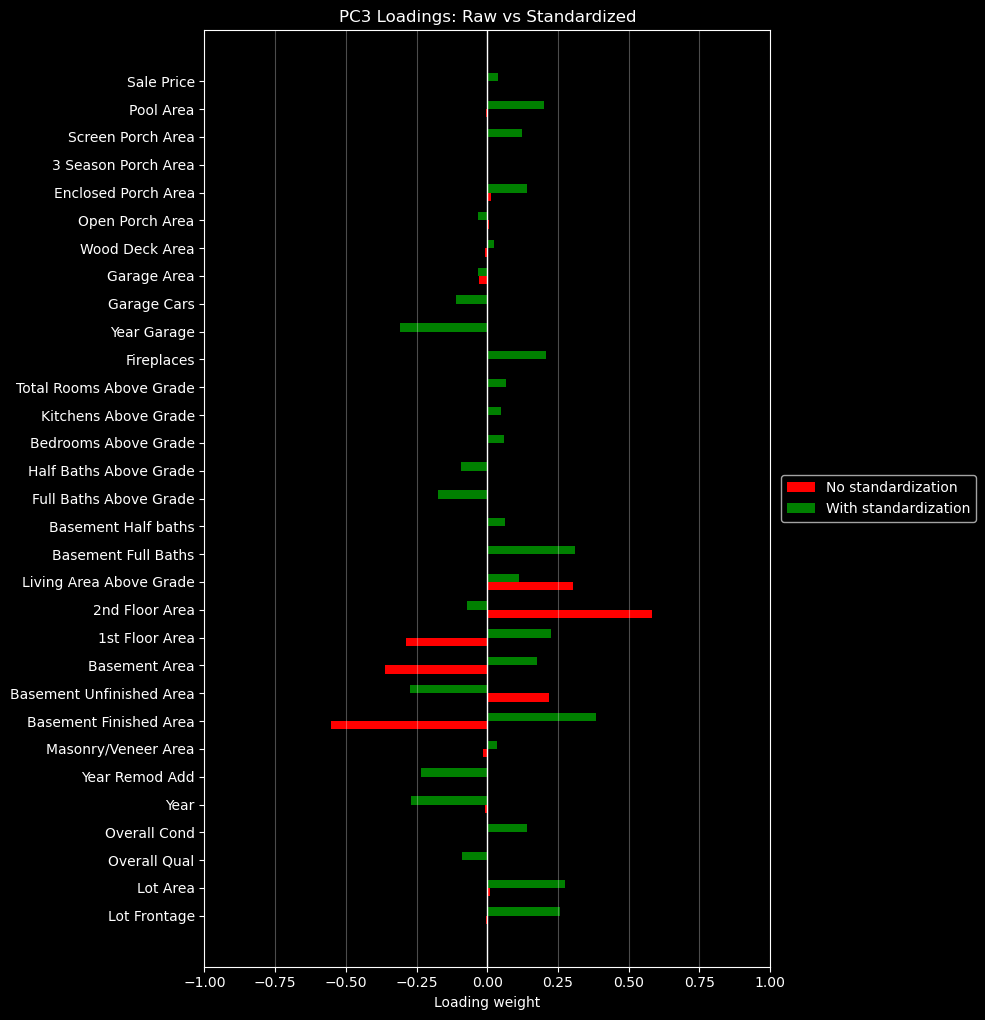

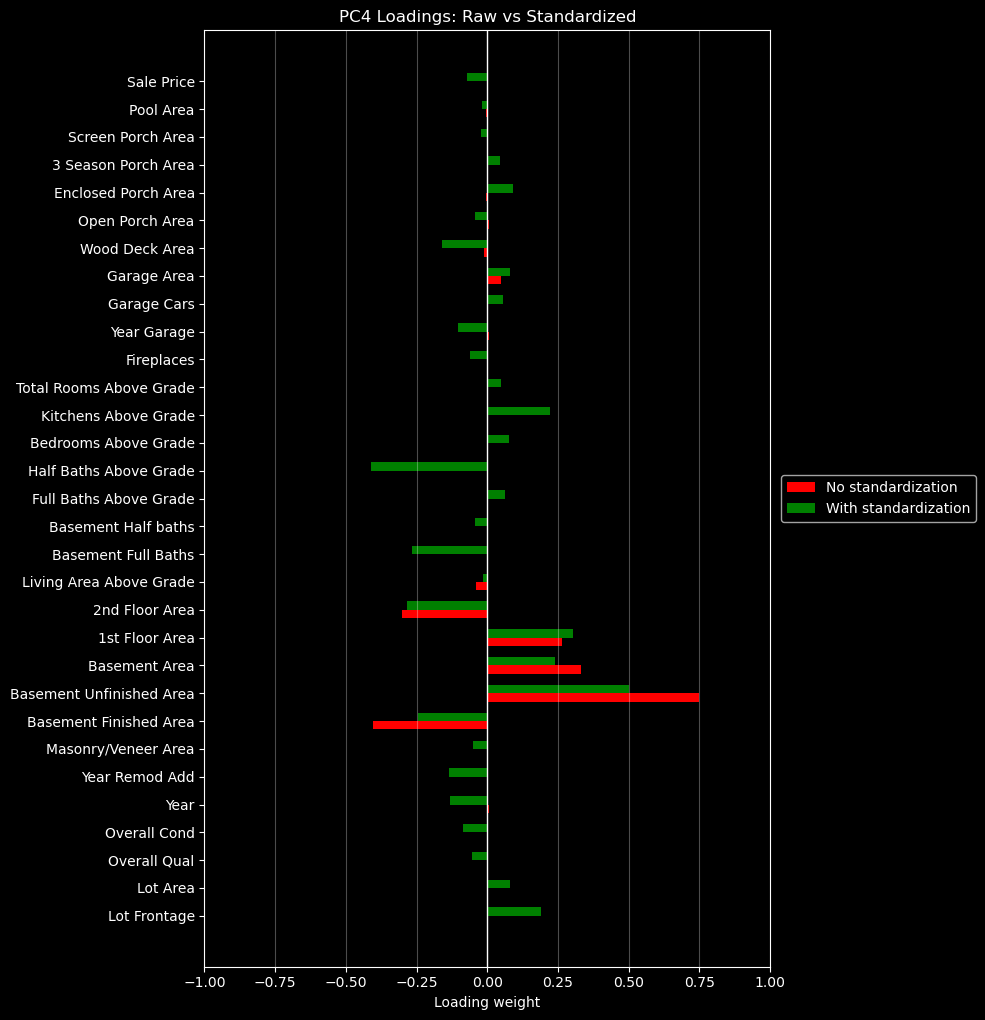

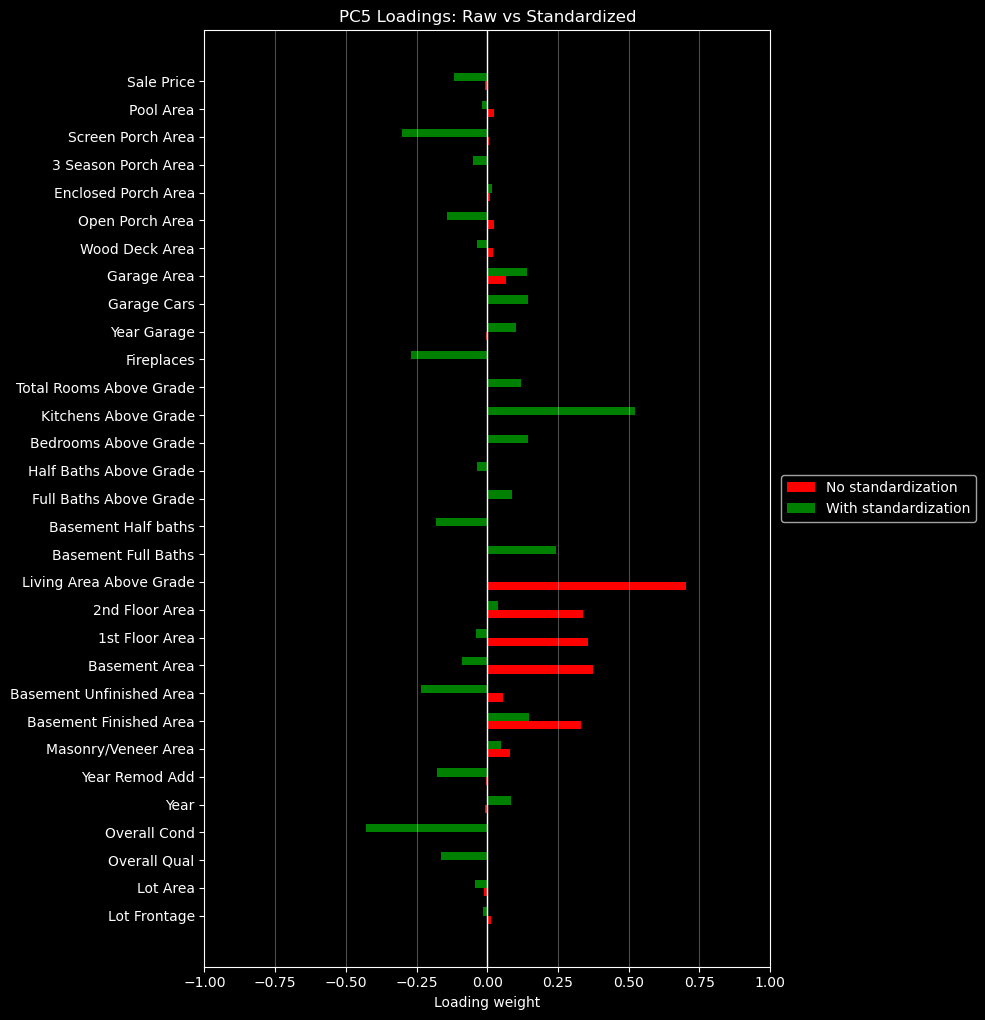

In [4]:
# -------------------------------------------------
# Extract loadings
# -------------------------------------------------
loadings_raw = pca_raw.components_
loadings_std = pca_std.components_

feature_names = np.array(df.columns)
n_components = loadings_raw.shape[0]

# -------------------------------------------------
# Horizontal barplots: raw vs standardized
# -------------------------------------------------
for i in range(5):
    y = np.arange(len(feature_names))
    height = 0.3

    fig, ax = plt.subplots(figsize=(10, height * len(feature_names) + 1))

    ax.barh(
        y - height / 2,
        loadings_raw[i],
        height=height,
        color="red",
        label="No standardization"
    )

    ax.barh(
        y + height / 2,
        loadings_std[i],
        height=height,
        color="green",
        label="With standardization"
    )

    ax.set_xlim(-1, 1)

    ax.set_yticks(y)
    ax.set_yticklabels(feature_names)
    ax.axvline(0, linewidth=1)

    ax.set_title(f"PC{i+1} Loadings: Raw vs Standardized")
    ax.set_xlabel("Loading weight")

    # ---- Legend outside ----
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()


# Inspect top loadings of each PC

In [5]:
def display_top_loadings_per_pc(
    pca_raw: PCA,
    pca_std: PCA,
    feature_names,
    top_n: int = 3,
    n_pcs: int = 5
):
    """
    Displays separate DataFrames PER PC for:
      - RAW PCA
      - STANDARDIZED PCA

    Each DataFrame contains EXACTLY top_n features,
    selected by absolute loading magnitude (sign preserved).
    """

    def display_for_one_pca(pca: PCA, label: str):
        comps = pca.components_
        n_use = min(n_pcs, comps.shape[0])

        print(f"\n===== {label} PCA: Top {top_n} |loadings| for first {n_use} PCs =====")

        for i in range(n_use):
            w = comps[i]

            # indices of top |loadings|
            idx = np.argsort(np.abs(w))[::-1][:top_n]

            df_pc = pd.DataFrame({
                "feature": feature_names[idx],
                "loading": w[idx],
                "abs_loading": np.abs(w[idx])
            }).sort_values("abs_loading", ascending=False).drop(columns="abs_loading")

            print(f"\n{label} PCA — PC{i+1}")
            display(df_pc.reset_index(drop=True))

    display_for_one_pca(pca_raw, "RAW")
    display_for_one_pca(pca_std, "STANDARDIZED")


# -------------------------------------------------
# Usage
# -------------------------------------------------
feature_names = df.columns.to_numpy()

display_top_loadings_per_pc(
    pca_raw=pca_raw,
    pca_std=pca_std,
    feature_names=feature_names,
    top_n=5,
    n_pcs=3
)


===== RAW PCA: Top 5 |loadings| for first 3 PCs =====

RAW PCA — PC1


,feature,loading
0,Sale Price,0.999538
1,Lot Area,0.029540
2,Living Area Above Grade,0.004410
3,Basement Area,0.003275
4,1st Floor Area,0.002819



RAW PCA — PC2


,feature,loading
0,Lot Area,0.999452
1,Sale Price,-0.029620
2,1st Floor Area,0.007566
3,Basement Finished Area,0.007321
4,Basement Area,0.006904



RAW PCA — PC3


...

,feature,loading
0,Sale Price,0.309276
1,Overall Qual,0.290410
2,Living Area Above Grade,0.277319
3,Garage Cars,0.270406
4,Garage Area,0.263955



STANDARDIZED PCA — PC2


,feature,loading
0,2nd Floor Area,0.452107
1,Bedrooms Above Grade,0.397239
2,Total Rooms Above Grade,0.346994
3,Living Area Above Grade,0.283827
4,Basement Full Baths,-0.246177



STANDARDIZED PCA — PC3


,feature,loading
0,Basement Finished Area,0.385943
1,Basement Full Baths,0.310142
2,Year Garage,-0.307253
3,Lot Area,0.274413
4,Basement Unfinished Area,-0.271839


# View variance explained for each PC

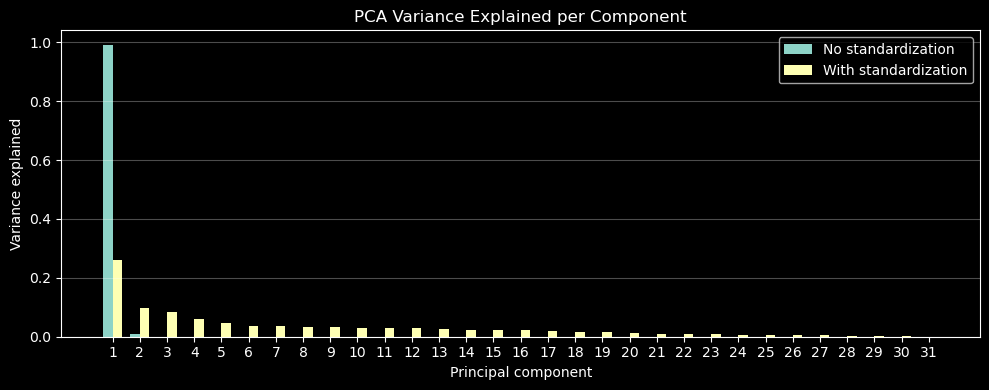

In [6]:
# -------------------------------------------------
# Variance explained (per component)
# -------------------------------------------------
var_raw = pca_raw.explained_variance_ratio_
var_std = pca_std.explained_variance_ratio_

x = np.arange(1, len(var_raw) + 1)
width = 0.35

# -------------------------------------------------
# Bar plot: variance explained per PC
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    x - width / 2,
    var_raw,
    width=width,
    label="No standardization"
)

ax.bar(
    x + width / 2,
    var_std,
    width=width,
    label="With standardization"
)

ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained")
ax.set_title("PCA Variance Explained per Component")
ax.set_xticks(x)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# Scatterplot of first two PC's

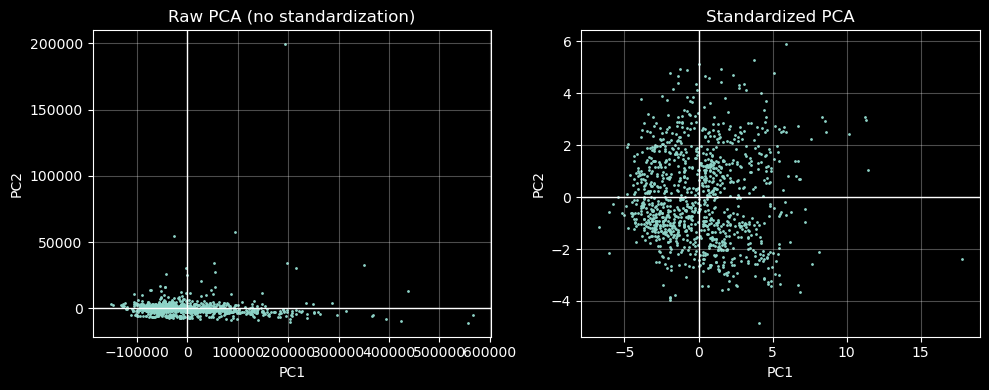

In [7]:
# -------------------------------------------------
# Project data onto first two PCs
# -------------------------------------------------
X_pca_raw_2d = pca_raw.transform(df.values)[:, :2]
X_pca_std_2d = pca_std.transform(StandardScaler().fit_transform(df.values))[:, :2]

# -------------------------------------------------
# Side-by-side scatter plots
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

# ---- Raw PCA ----
axes[0].scatter(
    X_pca_raw_2d[:, 0],
    X_pca_raw_2d[:, 1],
    s=1
)
axes[0].axhline(0, linewidth=1)
axes[0].axvline(0, linewidth=1)
axes[0].set_title("Raw PCA (no standardization)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

# ---- Standardized PCA ----
axes[1].scatter(
    X_pca_std_2d[:, 0],
    X_pca_std_2d[:, 1],
    s=1
)
axes[1].axhline(0, linewidth=1)
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Standardized PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Reconstruction error vs k

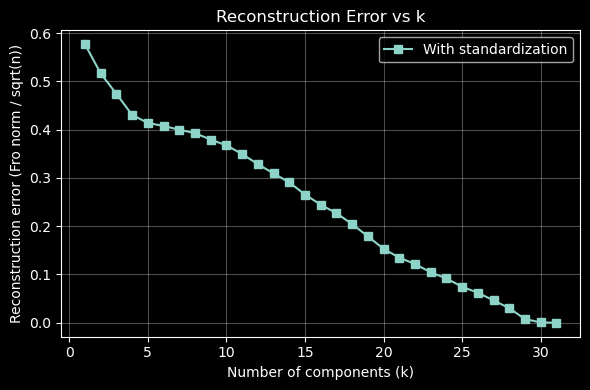

In [8]:
# -------------------------------------------------
# Data matrix (raw)
# -------------------------------------------------
X_raw = df.values   # assumes df already exists and is numeric

# -------------------------------------------------
# Reconstruction error vs k
# -------------------------------------------------
def reconstruction_error_curve(X: np.ndarray, standardize: bool = False):
    """
    Returns per-k reconstruction error (Frobenius norm / sqrt(n_samples)),
    interpretable as average per-row reconstruction magnitude.
    """
    if standardize:
        sc = StandardScaler()
        X_work = sc.fit_transform(X)
    else:
        X_work = X.copy()

    n, p = X_work.shape
    errs = []
    ks = np.arange(1, p+1)

    for k in ks:
        pca_k = PCA(n_components=k)
        Z = pca_k.fit_transform(X_work)
        X_hat = pca_k.inverse_transform(Z)
        #err = np.linalg.norm(X_work - X_hat, ord="fro") / np.sqrt(n)
        err = np.abs(X_work - X_hat).mean()
        errs.append(err)

    return ks, np.array(errs)

ks_raw, err_raw = reconstruction_error_curve(X_raw, standardize=False)
ks_std, err_std = reconstruction_error_curve(X_raw, standardize=True)

# -------------------------------------------------
# Plot (log-log)
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ks_std, err_std, marker="s", label="With standardization")

ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Reconstruction error (Fro norm / sqrt(n))")
ax.set_title("Reconstruction Error vs k")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()